# Time Series Forecasting: Electricity Consumption in Romania

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1 | Data Collection and Preprocessing

In [2]:
# Load data
df = pd.read_csv(
    "./data/electricity_consumption_and_production.csv",
    parse_dates=["DateTime"],
    index_col="DateTime"
)
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")
df.head()

Dataset shape: (54161, 9)
Date range: 2019-01-01 -> 2025-03-19


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


### Preprocessing Pipeline

The raw data is hourly, and I need it at a daily level. I apply the same preprocessing logic as in the lecture:
1. **Daily resampling** (mean) to compute the average consumption per day.
2. **Reindex** to a complete daily range to identify any missing days.
3. **Linear interpolation** to fill in the missing daily values.

In [3]:
def preprocess_series(df: pd.DataFrame, column: str) -> pd.Series:
    """Preprocessing pipeline: hourly -> daily series."""
    series = df[column]

    # Resample hourly -> daily (mean)
    daily = series.resample("D").mean()

    # Fill missing days via linear interpolation
    full_range = pd.date_range(start=daily.index.min(), end=daily.index.max(), freq="D")
    daily = daily.reindex(full_range).interpolate(method="linear")

    return daily


consumption = preprocess_series(df, "Consumption")

print(f"Daily observations : {len(consumption)}")
print(f"Period             : {consumption.index.min().date()} -> {consumption.index.max().date()}")
print(f"Missing after fill : {consumption.isna().sum()}")
print(f"Mean consumption   : {consumption.mean():.1f} MW")

Daily observations : 2270
Period             : 2019-01-01 -> 2025-03-19
Missing after fill : 0
Mean consumption   : 6526.8 MW


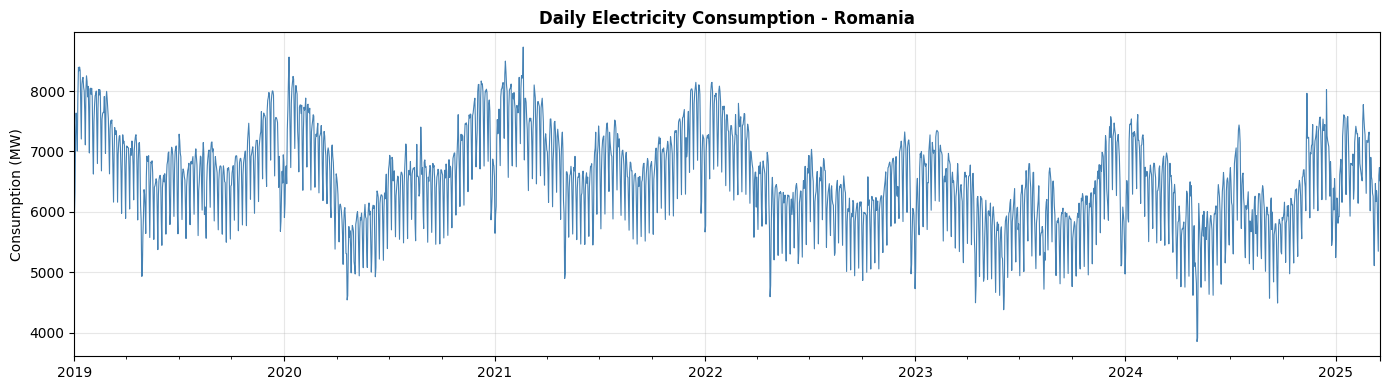

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
consumption.plot(ax=ax, color="steelblue", lw=0.8)
ax.set_title("Daily Electricity Consumption - Romania", fontsize=12, fontweight="bold")
ax.set_ylabel("Consumption (MW)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2 | Exploratory Data Analysis (EDA)

### Seasonal Decomposition

For the daily data, I use a **period of 7** to capture weekly seasonality.

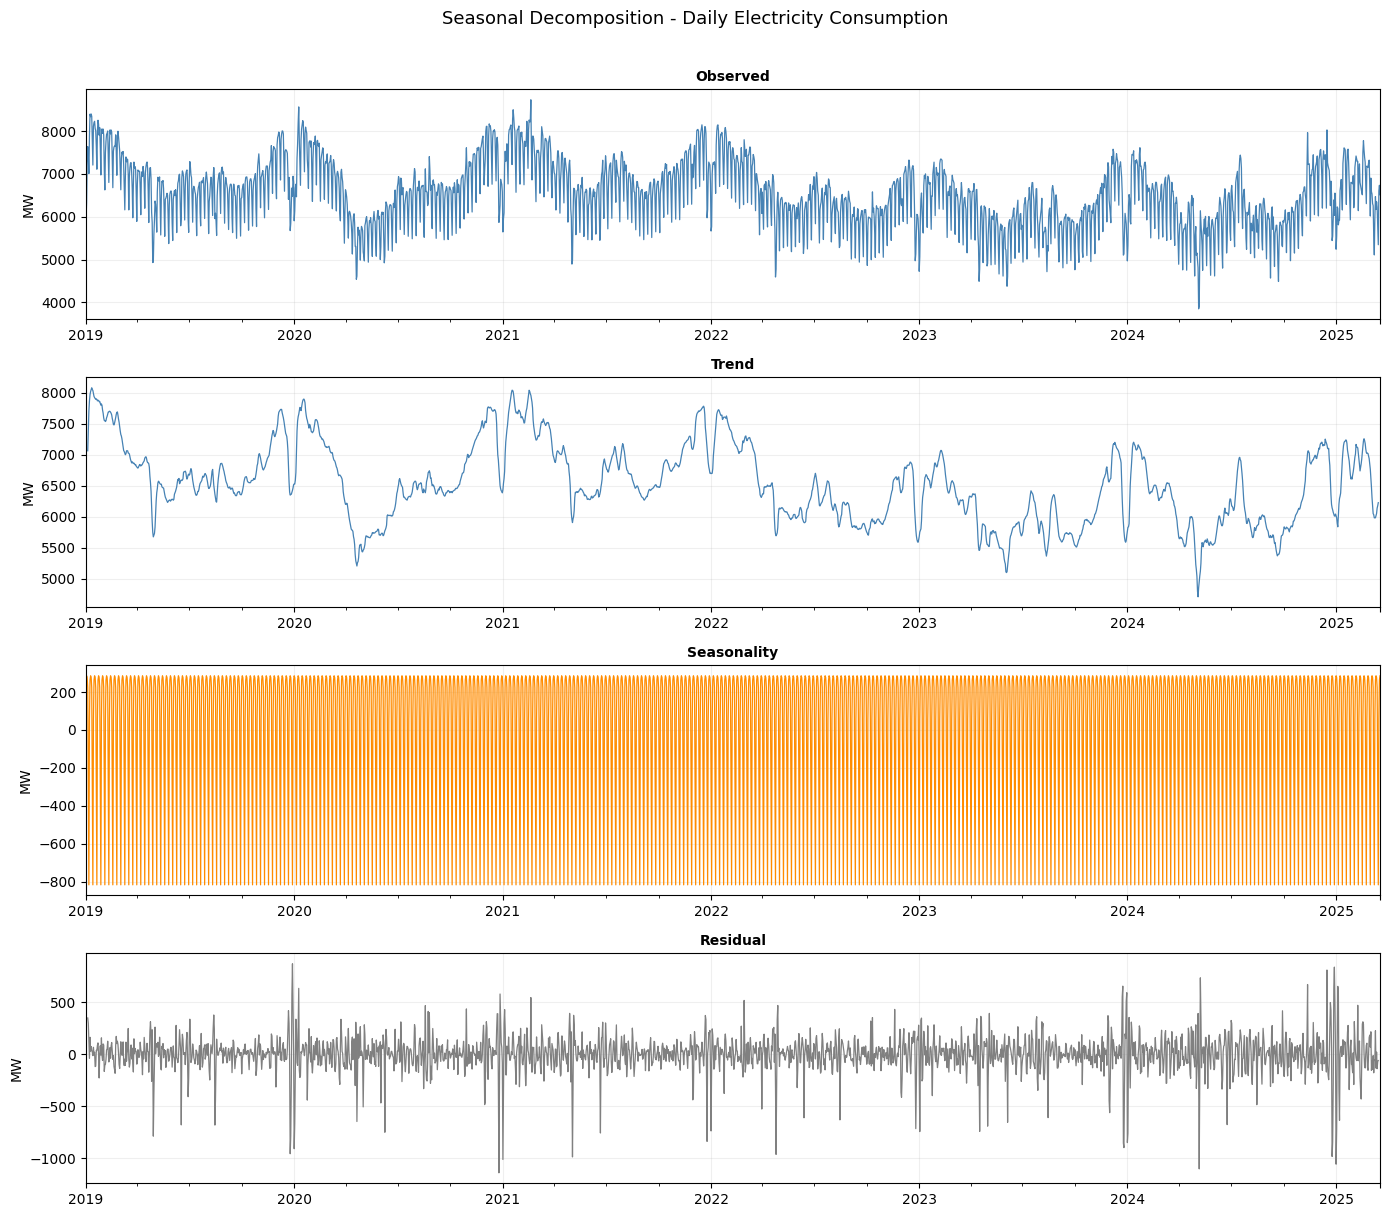

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(consumption, model="additive", period=7)

components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
titles     = ["Observed", "Trend", "Seasonality", "Residual"]
colors     = ["steelblue", "steelblue", "darkorange", "gray"]

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
for ax, comp, title, color in zip(axes, components, titles, colors):
    comp.plot(ax=ax, color=color, lw=0.9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("MW")
    ax.grid(True, alpha=0.2)

plt.suptitle("Seasonal Decomposition - Daily Electricity Consumption", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Seasonal Patterns by Day of Week

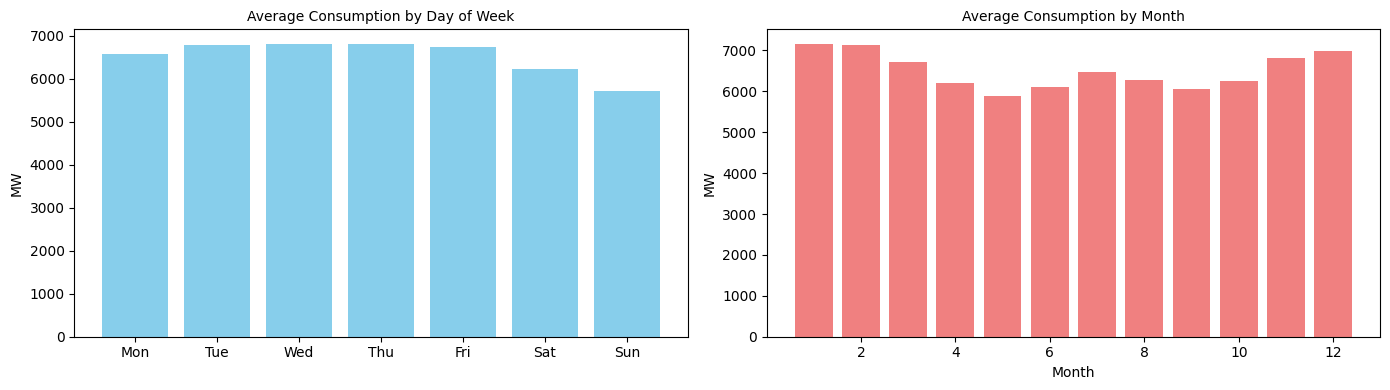

In [6]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_avg = consumption.groupby(consumption.index.dayofweek).mean()

month_avg = consumption.groupby(consumption.index.month).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(day_names, dow_avg.values, color="skyblue")
ax1.set_title("Average Consumption by Day of Week", fontsize=10)
ax1.set_ylabel("MW")

ax2.bar(range(1, 13), month_avg.values, color="lightcoral")
ax2.set_title("Average Consumption by Month", fontsize=10)
ax2.set_xlabel("Month")
ax2.set_ylabel("MW")

plt.tight_layout()
plt.show()

### ACF & PACF

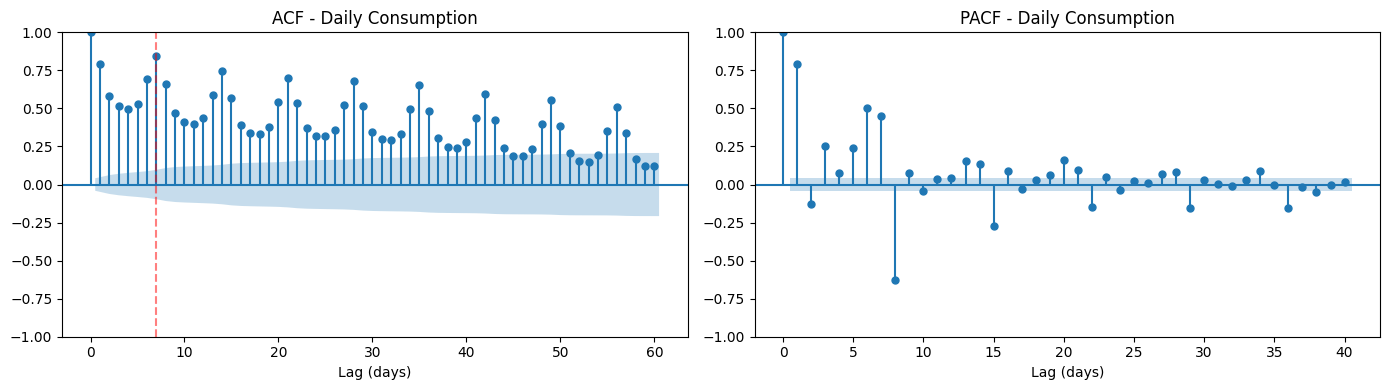

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(consumption, lags=60, ax=ax1, title="ACF - Daily Consumption")
ax1.axvline(x=7, color="red", linestyle="--", alpha=0.5, label="lag 7")
ax1.set_xlabel("Lag (days)")

plot_pacf(consumption, lags=40, method="ywm", ax=ax2, title="PACF - Daily Consumption")
ax2.set_xlabel("Lag (days)")

plt.tight_layout()
plt.show()

### Stationarity - ADF Test

In [8]:
from statsmodels.tsa.stattools import adfuller

# I use the same stationarity test function as in the lecture
def adf_stationarity_test(series: pd.Series) -> dict:
    result = adfuller(series)
    p_value = result[1]
    return {
        "ADF Statistic": round(result[0], 4),
        "p-value": round(p_value, 4),
        "Stationary": p_value < 0.05
    }

adf_orig = adf_stationarity_test(consumption)
adf_diff = adf_stationarity_test(consumption.diff().dropna())

result_df = pd.DataFrame([adf_orig, adf_diff], index=["Original", "Differenced"])


# 3 | Key Metrics

In [9]:
from darts import TimeSeries
from darts.metrics import mape, mae, mse, mql
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Convert to Darts TimeSeries
ts = TimeSeries.from_series(consumption, freq="D")

# Test set = 45 days (the maximum forecast horizon)
TEST_SIZE = 45
HORIZONS  = [15, 30, 45]

train_ts = ts[:-TEST_SIZE]
val_ts   = ts[-TEST_SIZE:]

print(f"Train: {len(train_ts)} days")
print(f"Test : {len(val_ts)} days  ({val_ts.start_time().date()} -> {val_ts.end_time().date()})")

Train: 2225 days
Test : 45 days  (2025-02-03 -> 2025-03-19)


In [10]:
# I adapt the same evaluation utilities from the lecture for 3 forecast horizons
def calculate_metrics(actual_ts, pred_ts, q_low=0.1, q_high=0.9):
    """Point + probabilistic metrics."""
    is_prob = pred_ts.n_samples > 1
    median  = pred_ts.quantile(0.5) if is_prob else pred_ts
    return {
        "MAPE (%)": round(mape(actual_ts, median), 3),
        "MAE":      round(mae(actual_ts, median), 3),
        "MSE":      round(mse(actual_ts, median), 3),
        f"QL@{q_low}":  round(mql(actual_ts, pred_ts, q=q_low),  3) if is_prob else None,
        f"QL@{q_high}": round(mql(actual_ts, pred_ts, q=q_high), 3) if is_prob else None,
    }


def visualize_forecast(model_name, pred_ts, q_low=0.1, q_high=0.9):
    """Plot forecast for 15 / 30 / 45 days and print metrics table."""
    is_prob = pred_ts.n_samples > 1
    median  = pred_ts.quantile(0.5) if is_prob else pred_ts

    fig, ax = plt.subplots(figsize=(14, 5))

    # Plot the last 90 days of the training set for better visualization context
    train_ts[-90:].to_series().plot(ax=ax, label="Training data", color="steelblue", lw=1.8)
    val_ts.to_series().plot(ax=ax, label="Actual values",   color="green",    lw=1.8)
    median.to_series().plot(ax=ax, label="Forecast (median)", color="tomato",  lw=1.8)

    if is_prob:
        low  = pred_ts.quantile(q_low).values()[:, 0]
        high = pred_ts.quantile(q_high).values()[:, 0]
        ax.fill_between( 
            pred_ts.time_index, low, high,
            alpha=0.25, color="tomato",
            label=f"{int((1 - 2*q_low)*100)}% CI"
        )

    # Vertical lines for forecast horizons
    for h in HORIZONS:
        day = pred_ts.time_index[h - 1]
        ax.axvline(x=day, linestyle="--", alpha=0.5, label=f"{h}d cutoff")

    ax.set_title(f"{model_name} - Electricity Consumption Forecast", fontsize=12, fontweight="bold")
    ax.set_ylabel("Consumption (MW)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

    # Metrics for each horizon
    metrics_rows = []
    for h in HORIZONS:
        m = calculate_metrics(val_ts[:h], pred_ts[:h], q_low, q_high)
        metrics_rows.append({"Horizon": f"{h} days", **m})
    metrics_df = pd.DataFrame(metrics_rows).set_index("Horizon")

    print(f"\n{model_name} - Metrics:")
    display(metrics_df)
    return metrics_df

# 4 | Forecasting Models

I use the same models from the lecture, adapted for daily data (weekly seasonality with **s=7**).

---
## Model 1: SARIMA

In [11]:
from darts.models import ARIMA

def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 3)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 3)
    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)
    try:
        model = ARIMA(p=p, d=d, q=q, seasonal_order=(P, D, Q, 7))  # s=7 for daily data
        model.fit(train_ts)
        pred = model.predict(n=TEST_SIZE)
        return mape(val_ts, pred)
    except Exception:
        return float("inf")

study_sarima = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_sarima.optimize(sarima_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE: {study_sarima.best_value:.2f}%")
print(f"Best params: {study_sarima.best_params}")

Best trial: 5. Best value: 5.3815:  35%|███▌      | 7/20 [00:11<00:22,  1.75s/it] c:\camp\Camp_2026_homework-main\new_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Best trial: 5. Best value: 5.3815:  75%|███████▌  | 15/20 [00:46<00:24,  4.82s/it]c:\camp\Camp_2026_homework-main\new_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Best trial: 5. Best value: 5.3815:  85%|████████▌ | 17/20 [00:55<00:13,  4.41s/it]c:\camp\Camp_2026_homework-main\new_venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Best trial: 5. Best value: 5.38


Best MAPE: 5.38%
Best params: {'p': 2, 'd': 0, 'q': 0, 'P': 2, 'D': 1, 'Q': 2}


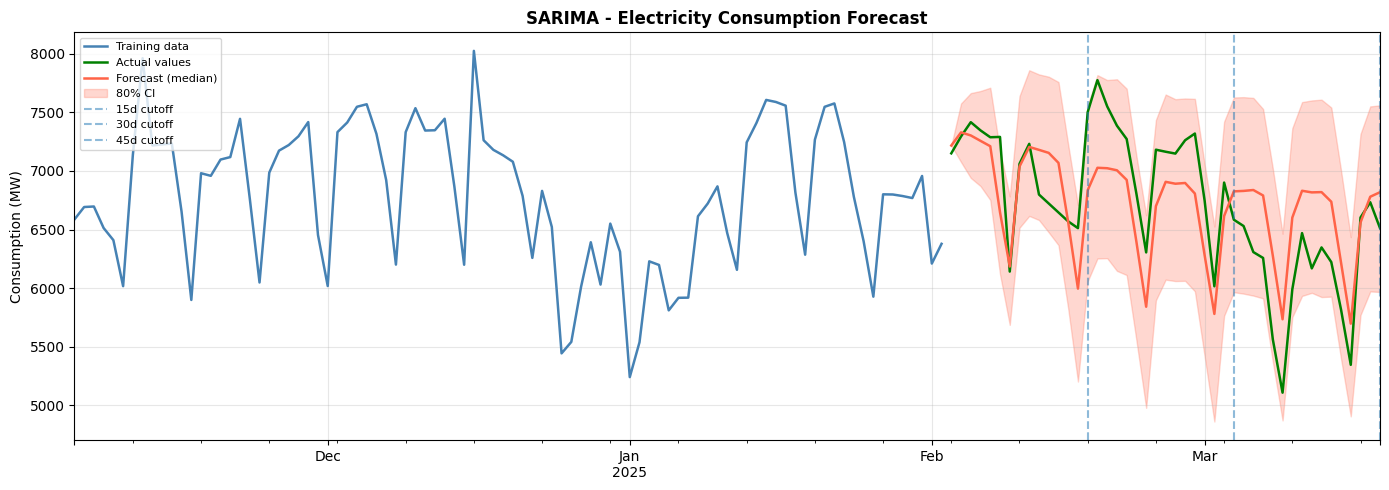


SARIMA - Metrics:


,MAPE (%),MAE,MSE,QL@0.1,QL@0.9
Horizon,,,,,
15 days,3.382,236.125,111288.696,124.358,111.872
30 days,4.506,317.356,144251.418,182.418,95.751
45 days,5.407,355.107,170649.323,150.119,143.196


In [12]:
bp = study_sarima.best_params
sarima_model = ARIMA(p=bp["p"], d=bp["d"], q=bp["q"],
                     seasonal_order=(bp["P"], bp["D"], bp["Q"], 7))
sarima_model.fit(train_ts)
sarima_pred = sarima_model.predict(n=TEST_SIZE, num_samples=500)

sarima_metrics = visualize_forecast("SARIMA", sarima_pred)

---
## Model 2: Exponential Smoothing (Holt-Winters)

In [13]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

TREND_MAP    = {"additive": ModelMode.ADDITIVE, "multiplicative": ModelMode.MULTIPLICATIVE, "none": ModelMode.NONE}
SEASONAL_MAP = {"additive": SeasonalityMode.ADDITIVE, "multiplicative": SeasonalityMode.MULTIPLICATIVE}

def es_objective(trial):
    trend_str    = trial.suggest_categorical("trend",    ["additive", "multiplicative", "none"])
    seasonal_str = trial.suggest_categorical("seasonal", ["additive", "multiplicative"])
    damped       = trial.suggest_categorical("damped",   [True, False])
    if trend_str == "none" and damped:
        return float("inf")
    try:
        model = ExponentialSmoothing(
            trend=TREND_MAP[trend_str], seasonal=SEASONAL_MAP[seasonal_str],
            damped=damped, seasonal_periods=7,
        )
        model.fit(train_ts)
        pred = model.predict(n=TEST_SIZE)
        return mape(val_ts, pred)
    except Exception:
        return float("inf")

study_es = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_es.optimize(es_objective, n_trials=15, show_progress_bar=True)
print(f"\nBest MAPE: {study_es.best_value:.2f}%")
print(f"Best params: {study_es.best_params}")

Best trial: 6. Best value: 7.34018: 100%|██████████| 15/15 [00:05<00:00,  2.84it/s]


Best MAPE: 7.34%
Best params: {'trend': 'multiplicative', 'seasonal': 'additive', 'damped': False}


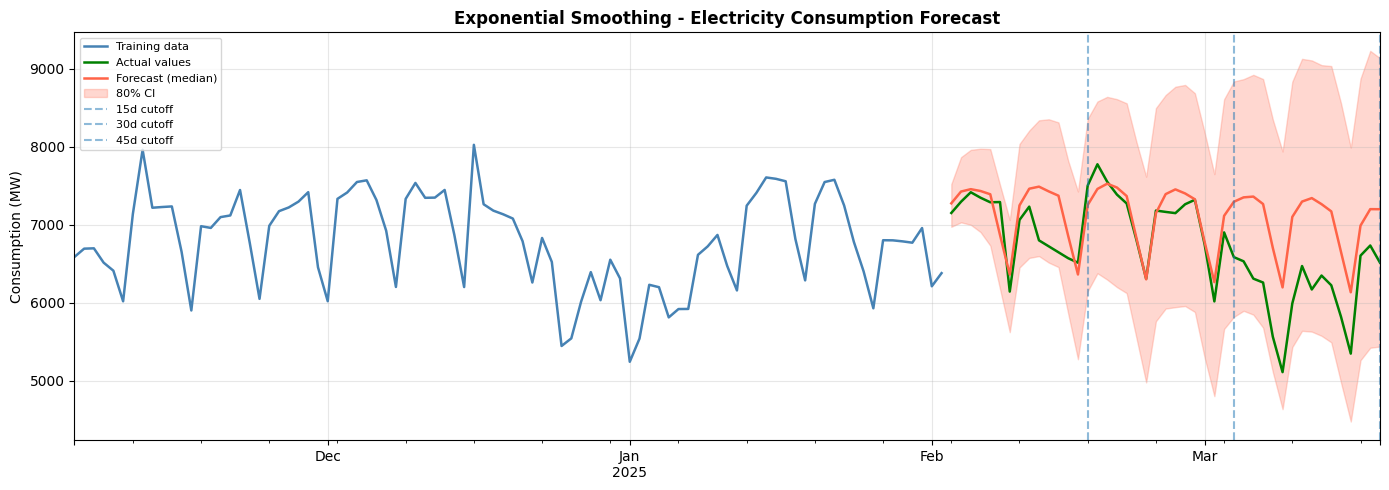


Exponential Smoothing - Metrics:


,MAPE (%),MAE,MSE,QL@0.1,QL@0.9
Horizon,,,,,
15 days,4.221,289.646,135351.058,115.514,183.200
30 days,3.302,227.168,97514.506,183.482,233.815
45 days,7.076,445.572,341681.814,173.373,333.229


In [14]:
bp = study_es.best_params
es_model = ExponentialSmoothing(
    trend=TREND_MAP[bp["trend"]], seasonal=SEASONAL_MAP[bp["seasonal"]],
    damped=bp["damped"], seasonal_periods=7,
)
es_model.fit(train_ts)
es_pred = es_model.predict(n=TEST_SIZE, num_samples=500)

es_metrics = visualize_forecast("Exponential Smoothing", es_pred)

---
## Model 3: Prophet | complete the code but couldnt resolve problem with it 

In [15]:
from darts.models import Prophet

def prophet_objective(trial):
    cps = trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True)
    sps = trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True)
    try:
        model = Prophet(changepoint_prior_scale=cps, seasonality_prior_scale=sps)
        model.fit(train_ts)
        pred = model.predict(n=TEST_SIZE)
        return mape(val_ts, pred)
    except Exception:
        return float("inf")

study_prophet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_prophet.optimize(prophet_objective, n_trials=15, show_progress_bar=True)
print(f"\nBest MAPE: {study_prophet.best_value:.2f}%")
print(f"Best params: {study_prophet.best_params}")

Best trial: 0. Best value: inf: 100%|██████████| 15/15 [00:00<00:00, 373.01it/s]


Best MAPE: inf%
Best params: {'changepoint_prior_scale': 0.010253509690168494, 'seasonality_prior_scale': 7.114476009343421}


In [21]:
# bp = study_prophet.best_params
# prophet_model = Prophet(
#     changepoint_prior_scale=bp["changepoint_prior_scale"],
#     seasonality_prior_scale=bp["seasonality_prior_scale"],
# )
# prophet_model.fit(train_ts)
# prophet_pred = prophet_model.predict(n=TEST_SIZE, num_samples=500)

# prophet_metrics = visualize_forecast("Prophet", prophet_pred)

---
## Model 4: XGBoost

In [17]:
from darts.models import XGBModel

def xgb_objective(trial):
    lags  = trial.suggest_int("lags", 7, 30)
    n_est = trial.suggest_int("n_estimators", 50, 300)
    depth = trial.suggest_int("max_depth", 2, 8)
    lr    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    sub   = trial.suggest_float("subsample", 0.6, 1.0)
    try:
        model = XGBModel(lags=lags, n_estimators=n_est, max_depth=depth,
                         learning_rate=lr, subsample=sub, random_state=42)
        model.fit(train_ts)
        pred = model.predict(n=TEST_SIZE, series=train_ts)
        return mape(val_ts, pred)
    except Exception:
        return float("inf")

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE: {study_xgb.best_value:.2f}%")
print(f"Best params: {study_xgb.best_params}")

Best trial: 17. Best value: 5.99997: 100%|██████████| 20/20 [00:02<00:00,  6.88it/s]


Best MAPE: 6.00%
Best params: {'lags': 18, 'n_estimators': 250, 'max_depth': 4, 'learning_rate': 0.17932503411658274, 'subsample': 0.8287629592745835}


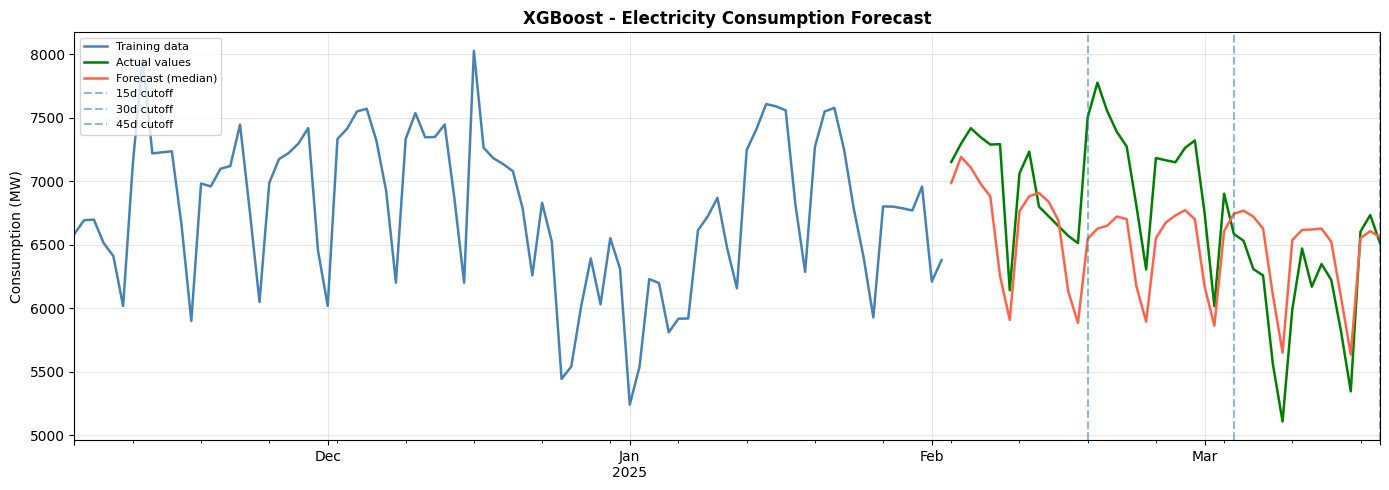


XGBoost - Metrics:


,MAPE (%),MAE,MSE,QL@0.1,QL@0.9
Horizon,,,,,
15 days,5.233,370.245,219744.898,None,None
30 days,6.411,457.193,289029.049,None,None
45 days,6.000,407.098,233041.466,None,None


In [18]:
bp = study_xgb.best_params
xgb_model = XGBModel(
    lags=bp["lags"], n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
    learning_rate=bp["learning_rate"], subsample=bp["subsample"], random_state=42,
)
xgb_model.fit(train_ts)
xgb_pred = xgb_model.predict(n=TEST_SIZE, series=train_ts)

xgb_metrics = visualize_forecast("XGBoost", xgb_pred)

# 5 | Model Comparison

In [19]:
model_results = {
    "SARIMA":              sarima_metrics,
    "Exp. Smoothing":      es_metrics,
    #"Prophet":             prophet_metrics,
    "XGBoost":             xgb_metrics,
}

# MAPE by each horizon
mape_comparison = pd.DataFrame({
    model: df["MAPE (%)"]
    for model, df in model_results.items()
})

mape_comparison.style \
    .background_gradient(cmap="RdYlGn_r", axis=None) \
    .format("{:.2f}") \
    .set_caption("MAPE (%) per model and horizon - lower is better (green)")

,SARIMA,Exp. Smoothing,XGBoost
Horizon,,,
15 days,3.38,4.22,5.23
30 days,4.51,3.30,6.41
45 days,5.41,7.08,6.00


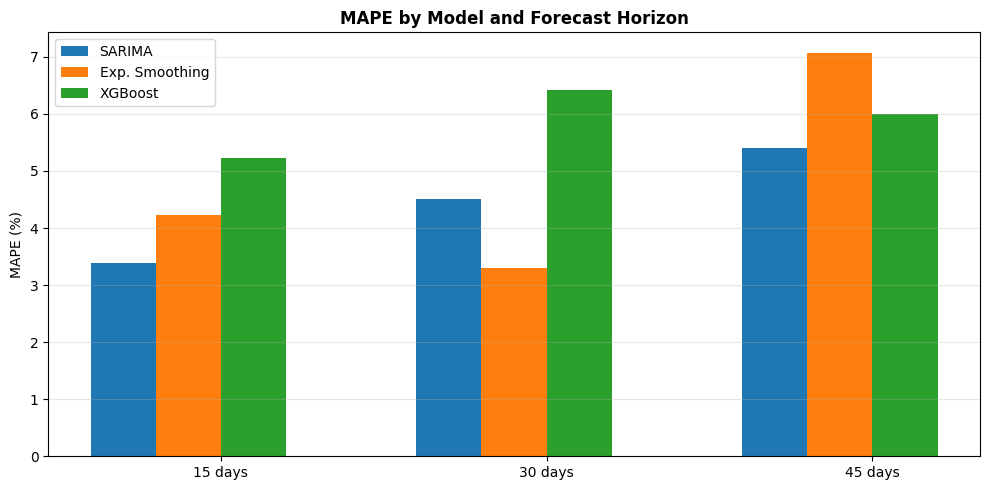

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(HORIZONS))
width = 0.2

for i, (model, df) in enumerate(model_results.items()):
    ax.bar(x + i * width, df["MAPE (%)"].values, width, label=model)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"{h} days" for h in HORIZONS])
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE by Model and Forecast Horizon", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()